YOLO + SAHI + Crop Classifier + Soft Fusion Baseline

Pipeline:
Input image
   -> YOLOv8s / YOLOv11n detector
   -> SAHI / sliced inference để tăng phát hiện vật thể nhỏ
   -> Crop detected boxes
   -> MobileNetV2 hoặc EfficientNetB0 crop classifier
   -> Soft fusion giữa YOLO confidence và classifier confidence
   -> Final label + bbox + confidence

Ghi chú thẳng:
- Nếu dùng yolo11n.pt hoặc yolov8s.pt pretrained COCO, YOLO chỉ biết nhãn COCO.
- Muốn fusion nhãn thật sự ngon thì YOLO phải được train custom cùng hệ nhãn với classifier.
- Nếu dataset chỉ có image-level label như label_group, không có bbox ground-truth, thì không tính được detection mAP chuẩn.
- File này vẫn chạy được baseline image-level metric: Accuracy@1, Top-5 Accuracy, confidence trung bình, fallback ratio.

In [2]:
# Nếu thiếu thư viện, chạy lệnh này trong terminal/notebook:
# pip install ultralytics sahi opencv-python matplotlib scikit-learn openpyxl tqdm pandas pillow torch torchvision

import os
import json
import time
import random
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import cv2
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt

try:
    from ultralytics import YOLO
    from sahi import AutoDetectionModel
    from sahi.predict import get_sliced_prediction
    HAS_DETECTION_LIBS = True
except Exception as e:
    HAS_DETECTION_LIBS = False
    IMPORT_ERROR = e

In [ ]:
# ==============================
# 1. CONFIG - SỬA Ở ĐÂY
# ==============================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Sửa đúng đường dẫn máy em
DATA_DIR = r"E:\study\DoAnPython\project\data\raw"
CSV_PATH = os.path.join(DATA_DIR, "train.csv")
IMAGE_DIR = os.path.join(DATA_DIR, "train_images")

# Tên cột trong CSV
IMAGE_COL = "image"
LABEL_COL = "label_group"  # nếu dataset có cột class/category thì sửa lại

# Output
PROJECT_ROOT = Path("../")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "yolo_sahi_crop_classifier"
RESULTS_DIR = PROJECT_ROOT / "results" / "yolo_sahi_crop_classifier"
CROP_DIR = PROCESSED_DIR / "crops"

for folder in [PROCESSED_DIR, RESULTS_DIR, CROP_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Detector: chọn YOLOv11n hoặc YOLOv8s.
# Nếu có custom weight thì thay bằng đường dẫn best.pt.
YOLO_WEIGHTS = "yolo11n.pt"   # hoặc "yolov8s.pt"
USE_SAHI = True
DETECT_CONF = 0.25
DETECT_IOU = 0.50
YOLO_IMGSZ = 640
MAX_DET = 20

# SAHI slicing config
SLICE_HEIGHT = 512
SLICE_WIDTH = 512
OVERLAP_HEIGHT_RATIO = 0.20
OVERLAP_WIDTH_RATIO = 0.20

# Crop classifier
CLASSIFIER_BACKBONE = "efficientnet_b0"  # "efficientnet_b0" hoặc "mobilenet_v2"
IMG_SIZE = 224
BATCH_SIZE = 8
NUM_WORKERS = 0
EPOCHS = 3
LR = 1e-4
FREEZE_BACKBONE = False
VAL_SIZE = 0.20

# Test nhanh: 500/1000. Chạy full thì None.
MAX_IMAGES = None

# Soft fusion: alpha càng cao càng tin YOLO.
FUSION_ALPHA = 0.35

# Cache
USE_CACHED_DETECTIONS = True
USE_CACHED_CROPS = True

print("Device:", DEVICE)
print("CSV_PATH :", CSV_PATH, "OK" if os.path.exists(CSV_PATH) else "MISSING")
print("IMAGE_DIR:", IMAGE_DIR, "OK" if os.path.exists(IMAGE_DIR) else "MISSING")
print("YOLO_WEIGHTS:", YOLO_WEIGHTS)
print("USE_SAHI:", USE_SAHI)

Device: cuda:0
CSV_PATH : E:\study\DoAnPython\project\data\raw\train.csv OK
IMAGE_DIR: E:\study\DoAnPython\project\data\raw\train_images OK
YOLO_WEIGHTS: yolo11n.pt
USE_SAHI: True


In [4]:
# ==============================
# 2. ĐỌC DATA
# ==============================

def load_dataframe() -> pd.DataFrame:
    if not os.path.exists(CSV_PATH):
        raise FileNotFoundError(f"Không tìm thấy CSV_PATH: {CSV_PATH}")
    if not os.path.exists(IMAGE_DIR):
        raise FileNotFoundError(f"Không tìm thấy IMAGE_DIR: {IMAGE_DIR}")

    df = pd.read_csv(CSV_PATH)
    required_cols = [IMAGE_COL, LABEL_COL]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"CSV thiếu cột {missing_cols}. CSV hiện có: {list(df.columns)}")

    df = df.copy()
    df["image_path"] = df[IMAGE_COL].apply(lambda x: os.path.join(IMAGE_DIR, str(x)))
    df = df[df["image_path"].apply(os.path.exists)].reset_index(drop=True)
    df[LABEL_COL] = df[LABEL_COL].astype(str)

    if MAX_IMAGES is not None:
        df = df.sample(n=min(MAX_IMAGES, len(df)), random_state=SEED).reset_index(drop=True)

    print("Số ảnh dùng:", len(df))
    print("Số class:", df[LABEL_COL].nunique())
    print("Min ảnh/class:", df[LABEL_COL].value_counts().min())
    return df

In [5]:
# ==============================
# 3. LOAD DETECTOR
# ==============================

def load_detector():
    if not HAS_DETECTION_LIBS:
        raise ImportError(
            "Chưa import được ultralytics/sahi. Cài bằng: "
            "pip install ultralytics sahi opencv-python"
        ) from IMPORT_ERROR

    if USE_SAHI:
        print("Loading SAHI AutoDetectionModel...")
        detector = AutoDetectionModel.from_pretrained(
            model_type="ultralytics",
            model_path=YOLO_WEIGHTS,
            confidence_threshold=DETECT_CONF,
            device=DEVICE,
        )
        return detector

    print("Loading Ultralytics YOLO...")
    return YOLO(YOLO_WEIGHTS)


def detect_objects_sahi(image_path: str, detector) -> list[dict]:
    result = get_sliced_prediction(
        image=str(image_path),
        detection_model=detector,
        slice_height=SLICE_HEIGHT,
        slice_width=SLICE_WIDTH,
        overlap_height_ratio=OVERLAP_HEIGHT_RATIO,
        overlap_width_ratio=OVERLAP_WIDTH_RATIO,
        postprocess_type="NMS",
        postprocess_match_metric="IOU",
        postprocess_match_threshold=DETECT_IOU,
        verbose=0,
    )

    detections = []
    for pred in result.object_prediction_list:
        x1, y1, x2, y2 = pred.bbox.to_xyxy()
        detections.append({
            "x1": float(x1),
            "y1": float(y1),
            "x2": float(x2),
            "y2": float(y2),
            "yolo_label": str(pred.category.name),
            "yolo_class_id": int(pred.category.id),
            "yolo_conf": float(pred.score.value),
        })
    return detections


def detect_objects_yolo(image_path: str, yolo_model) -> list[dict]:
    results = yolo_model.predict(
        source=str(image_path),
        conf=DETECT_CONF,
        iou=DETECT_IOU,
        imgsz=YOLO_IMGSZ,
        max_det=MAX_DET,
        verbose=False,
    )

    r = results[0]
    detections = []
    names = r.names

    if r.boxes is None or len(r.boxes) == 0:
        return detections

    xyxy = r.boxes.xyxy.detach().cpu().numpy()
    confs = r.boxes.conf.detach().cpu().numpy()
    clss = r.boxes.cls.detach().cpu().numpy().astype(int)

    for box, conf, cls_id in zip(xyxy, confs, clss):
        x1, y1, x2, y2 = box.tolist()
        detections.append({
            "x1": float(x1),
            "y1": float(y1),
            "x2": float(x2),
            "y2": float(y2),
            "yolo_label": str(names.get(int(cls_id), str(cls_id))),
            "yolo_class_id": int(cls_id),
            "yolo_conf": float(conf),
        })
    return detections


def detect_objects(image_path: str, detector) -> list[dict]:
    if USE_SAHI:
        return detect_objects_sahi(image_path, detector)
    return detect_objects_yolo(image_path, detector)

In [6]:
# ==============================
# 4. BBOX UTILS + CROP
# ==============================

def clamp_box(x1, y1, x2, y2, w, h):
    x1 = int(max(0, min(round(float(x1)), w - 1)))
    y1 = int(max(0, min(round(float(y1)), h - 1)))
    x2 = int(max(1, min(round(float(x2)), w)))
    y2 = int(max(1, min(round(float(y2)), h)))

    if x2 <= x1:
        x2 = min(w, x1 + 1)
    if y2 <= y1:
        y2 = min(h, y1 + 1)
    return x1, y1, x2, y2


def choose_main_detection(detections: list[dict], image_width: int, image_height: int) -> dict:
    """Chọn bbox chính. Nếu không detect được thì fallback dùng full image."""
    if len(detections) == 0:
        return {
            "x1": 0,
            "y1": 0,
            "x2": image_width,
            "y2": image_height,
            "yolo_label": "full_image",
            "yolo_class_id": -1,
            "yolo_conf": 0.0,
            "det_score": 0.0,
            "used_fallback_full_image": True,
        }

    img_area = max(1, image_width * image_height)
    best = None
    best_score = -1.0

    for det in detections:
        x1, y1, x2, y2 = clamp_box(det["x1"], det["y1"], det["x2"], det["y2"], image_width, image_height)
        area = max(1, (x2 - x1) * (y2 - y1))
        area_ratio = area / img_area

        # confidence cao + diện tích không quá bé
        det_score = float(det["yolo_conf"]) * np.sqrt(area_ratio)
        if det_score > best_score:
            best_score = det_score
            best = dict(det)
            best.update({
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "det_score": float(det_score),
                "used_fallback_full_image": False,
            })

    return best


def crop_and_save(image_path: str, box: dict, crop_path: Path, pad_ratio: float = 0.04):
    img = Image.open(image_path).convert("RGB")
    w, h = img.size

    x1, y1, x2, y2 = box["x1"], box["y1"], box["x2"], box["y2"]
    bw, bh = x2 - x1, y2 - y1
    px, py = int(bw * pad_ratio), int(bh * pad_ratio)
    x1, y1, x2, y2 = clamp_box(x1 - px, y1 - py, x2 + px, y2 + py, w, h)

    crop = img.crop((x1, y1, x2, y2))
    crop.save(crop_path, quality=95)
    return x1, y1, x2, y2


def run_detection_and_crop(df: pd.DataFrame, detector) -> pd.DataFrame:
    detection_cache_csv = PROCESSED_DIR / "detections_main_box.csv"

    if USE_CACHED_DETECTIONS and detection_cache_csv.exists():
        print("Load detection cache:", detection_cache_csv)
        return pd.read_csv(detection_cache_csv)

    rows = []
    t0 = time.time()

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="YOLO/SAHI detect + crop"):
        image_path = row["image_path"]
        image_name = str(row[IMAGE_COL])
        true_label = str(row[LABEL_COL])

        try:
            img = Image.open(image_path).convert("RGB")
            w, h = img.size

            detections = detect_objects(image_path, detector)
            main_box = choose_main_detection(detections, w, h)

            stem = Path(image_name).stem
            crop_name = f"{idx:06d}_{stem}.jpg"
            crop_path = CROP_DIR / crop_name

            if (not USE_CACHED_CROPS) or (not crop_path.exists()):
                cx1, cy1, cx2, cy2 = crop_and_save(image_path, main_box, crop_path)
            else:
                cx1, cy1, cx2, cy2 = int(main_box["x1"]), int(main_box["y1"]), int(main_box["x2"]), int(main_box["y2"])

            rows.append({
                "row_id": idx,
                "image": image_name,
                "image_path": image_path,
                "crop_path": str(crop_path),
                "true_label": true_label,
                "x1": cx1,
                "y1": cy1,
                "x2": cx2,
                "y2": cy2,
                "yolo_label": main_box["yolo_label"],
                "yolo_class_id": main_box["yolo_class_id"],
                "yolo_conf": float(main_box["yolo_conf"]),
                "det_score": float(main_box["det_score"]),
                "used_fallback_full_image": bool(main_box["used_fallback_full_image"]),
                "num_detections": len(detections),
            })
        except Exception as e:
            print("Lỗi ảnh:", image_path, repr(e))

    det_df = pd.DataFrame(rows)
    det_df.to_csv(detection_cache_csv, index=False, encoding="utf-8-sig")

    print(f"Xong detect + crop trong {time.time() - t0:.1f}s")
    print("Saved:", detection_cache_csv)
    return det_df

In [7]:
# ==============================
# 5. DATASET + CLASSIFIER
# ==============================

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.03),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class CropDataset(Dataset):
    def __init__(self, data: pd.DataFrame, transform=None, return_meta: bool = False):
        self.df = data.reset_index(drop=True)
        self.transform = transform
        self.return_meta = return_meta

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row["crop_path"]).convert("RGB")
        except Exception:
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), color=(255, 255, 255))

        if self.transform:
            img = self.transform(img)

        label = int(row["label_id"])

        if self.return_meta:
            return img, label, idx
        return img, label


def prepare_train_val(det_df: pd.DataFrame):
    work_df = det_df[det_df["crop_path"].apply(os.path.exists)].copy().reset_index(drop=True)
    work_df["true_label"] = work_df["true_label"].astype(str)

    label_encoder = LabelEncoder()
    work_df["label_id"] = label_encoder.fit_transform(work_df["true_label"])
    class_names = label_encoder.classes_.tolist()
    num_classes = len(class_names)
    class_to_idx = {name: i for i, name in enumerate(class_names)}

    counts = work_df["label_id"].value_counts()
    can_stratify = (
        counts.min() >= 2
        and int(len(work_df) * VAL_SIZE) >= num_classes
        and int(len(work_df) * (1 - VAL_SIZE)) >= num_classes
    )

    if can_stratify:
        train_df, val_df = train_test_split(
            work_df,
            test_size=VAL_SIZE,
            random_state=SEED,
            stratify=work_df["label_id"],
        )
    else:
        print("Không stratify được vì class nhiều hoặc mỗi class quá ít ảnh. Dùng random split.")
        train_df, val_df = train_test_split(
            work_df,
            test_size=VAL_SIZE,
            random_state=SEED,
            shuffle=True,
        )

    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)

    label_path = RESULTS_DIR / "label_encoder_classes.json"
    with open(label_path, "w", encoding="utf-8") as f:
        json.dump(class_names, f, ensure_ascii=False, indent=2)

    print("Train:", train_df.shape)
    print("Val:", val_df.shape)
    print("Num classes:", num_classes)
    print("Saved label encoder:", label_path)

    return train_df, val_df, class_names, class_to_idx, num_classes


def build_crop_classifier(backbone_name: str, num_classes: int, freeze_backbone: bool = False):
    backbone_name = backbone_name.lower().strip()

    if backbone_name == "efficientnet_b0":
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

        if freeze_backbone:
            for name, param in model.named_parameters():
                if not name.startswith("classifier"):
                    param.requires_grad = False

    elif backbone_name == "mobilenet_v2":
        weights = models.MobileNet_V2_Weights.DEFAULT
        model = models.mobilenet_v2(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

        if freeze_backbone:
            for name, param in model.named_parameters():
                if not name.startswith("classifier"):
                    param.requires_grad = False
    else:
        raise ValueError("CLASSIFIER_BACKBONE chỉ nhận 'efficientnet_b0' hoặc 'mobilenet_v2'")

    return model

In [8]:
# ==============================
# 6. TRAIN / EVALUATE CLASSIFIER
# ==============================

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images = images.to(TORCH_DEVICE)
        labels = labels.to(TORCH_DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_count += images.size(0)

    return total_loss / max(1, total_count), total_correct / max(1, total_count)


@torch.no_grad()
def evaluate_classifier(model, loader, criterion, num_classes):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    all_probs = []
    all_labels = []
    all_indices = []

    for images, labels, indices in tqdm(loader, desc="Val", leave=False):
        images = images.to(TORCH_DEVICE)
        labels = labels.to(TORCH_DEVICE)

        logits = model(images)
        loss = criterion(logits, labels)
        probs = F.softmax(logits, dim=1)

        total_loss += loss.item() * images.size(0)
        total_correct += (probs.argmax(dim=1) == labels).sum().item()
        total_count += images.size(0)

        all_probs.append(probs.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())
        all_indices.append(indices.numpy())

    avg_loss = total_loss / max(1, total_count)
    acc = total_correct / max(1, total_count)
    probs = np.concatenate(all_probs, axis=0) if all_probs else np.empty((0, num_classes))
    labels = np.concatenate(all_labels, axis=0) if all_labels else np.empty((0,), dtype=int)
    indices = np.concatenate(all_indices, axis=0) if all_indices else np.empty((0,), dtype=int)

    return avg_loss, acc, probs, labels, indices


def train_classifier(train_df, val_df, num_classes):
    train_loader = DataLoader(
        CropDataset(train_df, train_transform),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    val_loader = DataLoader(
        CropDataset(val_df, val_transform, return_meta=True),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    model = build_crop_classifier(
        CLASSIFIER_BACKBONE,
        num_classes=num_classes,
        freeze_backbone=FREEZE_BACKBONE,
    ).to(TORCH_DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR,
        weight_decay=1e-4,
    )

    best_model_path = RESULTS_DIR / f"crop_classifier_{CLASSIFIER_BACKBONE}_best.pt"
    best_val_acc = -1.0
    history = []

    for epoch in range(1, EPOCHS + 1):
        print(f"\nEpoch {epoch}/{EPOCHS}")
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, _, _, _ = evaluate_classifier(model, val_loader, criterion, num_classes)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }
        history.append(row)
        print(row)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                "model_state_dict": model.state_dict(),
                "backbone": CLASSIFIER_BACKBONE,
                "img_size": IMG_SIZE,
                "num_classes": num_classes,
            }, best_model_path)
            print("Saved best model:", best_model_path)

    history_df = pd.DataFrame(history)
    history_csv = RESULTS_DIR / "crop_classifier_training_history.csv"
    history_df.to_csv(history_csv, index=False, encoding="utf-8-sig")

    checkpoint = torch.load(best_model_path, map_location=TORCH_DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    return model, criterion, val_loader, history_df, best_model_path

In [9]:
# ==============================
# 7. SOFT FUSION + METRIC
# ==============================

def soft_fusion(yolo_label, yolo_conf, cls_probs, class_names, class_to_idx, alpha=FUSION_ALPHA):
    """
    Nếu yolo_label nằm trong class_names:
        fused_score[label] = (1-alpha)*classifier_prob + alpha*yolo_conf
    Nếu không match label:
        final_label lấy từ classifier, final_conf vẫn gộp yolo_conf và classifier_conf.
    """
    cls_probs = np.asarray(cls_probs, dtype=np.float32)
    yolo_label = str(yolo_label)
    yolo_conf = float(yolo_conf)

    if yolo_label in class_to_idx:
        fused_scores = (1.0 - alpha) * cls_probs.copy()
        fused_scores[class_to_idx[yolo_label]] += alpha * yolo_conf
        final_idx = int(np.argmax(fused_scores))
        final_conf = float(fused_scores[final_idx])
        used_yolo_label_match = True
    else:
        final_idx = int(np.argmax(cls_probs))
        cls_conf = float(cls_probs[final_idx])
        final_conf = float(alpha * yolo_conf + (1.0 - alpha) * cls_conf)
        used_yolo_label_match = False

    classifier_idx = int(np.argmax(cls_probs))

    return {
        "final_label": class_names[final_idx],
        "final_label_id": final_idx,
        "final_conf": final_conf,
        "classifier_label": class_names[classifier_idx],
        "classifier_conf": float(cls_probs[classifier_idx]),
        "used_yolo_label_match": used_yolo_label_match,
    }


def run_final_evaluation(model, criterion, val_loader, val_df, class_names, class_to_idx, num_classes):
    val_loss, val_acc, val_probs, val_labels, val_indices = evaluate_classifier(
        model, val_loader, criterion, num_classes
    )

    prediction_rows = []
    for row_pos, local_idx in enumerate(val_indices):
        row = val_df.iloc[int(local_idx)].to_dict()
        probs = val_probs[row_pos]

        fused = soft_fusion(
            yolo_label=row["yolo_label"],
            yolo_conf=row["yolo_conf"],
            cls_probs=probs,
            class_names=class_names,
            class_to_idx=class_to_idx,
            alpha=FUSION_ALPHA,
        )

        top_k = min(5, num_classes)
        top_ids = np.argsort(-probs)[:top_k]
        top_labels = [class_names[int(i)] for i in top_ids]
        top_scores = [float(probs[int(i)]) for i in top_ids]

        prediction_rows.append({
            "image": row["image"],
            "image_path": row["image_path"],
            "crop_path": row["crop_path"],
            "true_label": row["true_label"],
            "x1": row["x1"],
            "y1": row["y1"],
            "x2": row["x2"],
            "y2": row["y2"],
            "yolo_label": row["yolo_label"],
            "yolo_conf": row["yolo_conf"],
            "num_detections": row["num_detections"],
            "used_fallback_full_image": row["used_fallback_full_image"],
            "classifier_label": fused["classifier_label"],
            "classifier_conf": fused["classifier_conf"],
            "final_label": fused["final_label"],
            "final_conf": fused["final_conf"],
            "used_yolo_label_match": fused["used_yolo_label_match"],
            "top5_labels": json.dumps(top_labels, ensure_ascii=False),
            "top5_scores": json.dumps(top_scores, ensure_ascii=False),
        })

    pred_df = pd.DataFrame(prediction_rows)

    true_labels = pred_df["true_label"].astype(str).values
    final_labels = pred_df["final_label"].astype(str).values
    clf_labels = pred_df["classifier_label"].astype(str).values

    final_acc = accuracy_score(true_labels, final_labels) if len(pred_df) else 0.0
    classifier_acc = accuracy_score(true_labels, clf_labels) if len(pred_df) else 0.0

    if len(pred_df):
        top5_hit = []
        for _, row in pred_df.iterrows():
            top5 = json.loads(row["top5_labels"])
            top5_hit.append(str(row["true_label"]) in top5)
        top5_acc = float(np.mean(top5_hit))
    else:
        top5_acc = 0.0

    summary = {
        "method": f"YOLO_SAHI_{CLASSIFIER_BACKBONE}_soft_fusion",
        "detector_weights": YOLO_WEIGHTS,
        "use_sahi": USE_SAHI,
        "classifier_backbone": CLASSIFIER_BACKBONE,
        "fusion_alpha": FUSION_ALPHA,
        "num_images_val": len(pred_df),
        "num_classes": num_classes,
        "classifier_accuracy@1": classifier_acc,
        "final_accuracy@1": final_acc,
        "classifier_top5_accuracy": top5_acc,
        "fallback_full_image_ratio": float(pred_df["used_fallback_full_image"].mean()) if len(pred_df) else 0.0,
        "avg_yolo_conf": float(pred_df["yolo_conf"].mean()) if len(pred_df) else 0.0,
        "avg_classifier_conf": float(pred_df["classifier_conf"].mean()) if len(pred_df) else 0.0,
        "avg_final_conf": float(pred_df["final_conf"].mean()) if len(pred_df) else 0.0,
        "yolo_label_match_ratio": float(pred_df["used_yolo_label_match"].mean()) if len(pred_df) else 0.0,
    }

    summary_df = pd.DataFrame([summary])

    pred_csv = RESULTS_DIR / "FINAL_yolo_sahi_crop_classifier_predictions.csv"
    summary_csv = RESULTS_DIR / "FINAL_yolo_sahi_crop_classifier_summary.csv"
    summary_xlsx = RESULTS_DIR / "FINAL_yolo_sahi_crop_classifier_summary.xlsx"

    pred_df.to_csv(pred_csv, index=False, encoding="utf-8-sig")
    summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")
    summary_df.to_excel(summary_xlsx, index=False)

    print("\nSUMMARY")
    print(summary_df.to_string(index=False))
    print("\nSaved:")
    print(pred_csv)
    print(summary_csv)
    print(summary_xlsx)

    if num_classes <= 50 and len(pred_df) > 0:
        print("\nClassification report:")
        print(classification_report(true_labels, final_labels, zero_division=0))
    else:
        print(f"\nBỏ qua classification_report vì num_classes={num_classes}.")

    return pred_df, summary_df

In [10]:
# ==============================
# 8. VISUALIZE + INFERENCE 1 ẢNH
# ==============================

def draw_prediction(row):
    img = cv2.imread(str(row["image_path"]))
    if img is None:
        print("Không đọc được ảnh:", row["image_path"])
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    x1, y1, x2, y2 = map(int, [row["x1"], row["y1"], row["x2"], row["y2"]])

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.gca().add_patch(
        plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=2)
    )
    title = (
        f"TRUE: {row['true_label']}\n"
        f"YOLO: {row['yolo_label']} ({row['yolo_conf']:.3f}) | "
        f"CLS: {row['classifier_label']} ({row['classifier_conf']:.3f})\n"
        f"FINAL: {row['final_label']} ({row['final_conf']:.3f})"
    )
    plt.title(title, fontsize=9)
    plt.axis("off")
    plt.show()


@torch.no_grad()
def classify_crop_pil(model, crop_pil):
    model.eval()
    x = val_transform(crop_pil).unsqueeze(0).to(TORCH_DEVICE)
    logits = model(x)
    probs = F.softmax(logits, dim=1).detach().cpu().numpy()[0]
    return probs


def predict_one_image(image_path, detector, model, class_names, class_to_idx):
    img = Image.open(image_path).convert("RGB")
    w, h = img.size

    detections = detect_objects(str(image_path), detector)
    main_box = choose_main_detection(detections, w, h)
    x1, y1, x2, y2 = clamp_box(main_box["x1"], main_box["y1"], main_box["x2"], main_box["y2"], w, h)

    crop = img.crop((x1, y1, x2, y2))
    probs = classify_crop_pil(model, crop)
    fused = soft_fusion(
        yolo_label=main_box["yolo_label"],
        yolo_conf=main_box["yolo_conf"],
        cls_probs=probs,
        class_names=class_names,
        class_to_idx=class_to_idx,
        alpha=FUSION_ALPHA,
    )

    return {
        "image_path": str(image_path),
        "bbox": [x1, y1, x2, y2],
        "yolo_label": main_box["yolo_label"],
        "yolo_conf": float(main_box["yolo_conf"]),
        "classifier_label": fused["classifier_label"],
        "classifier_conf": fused["classifier_conf"],
        "final_label": fused["final_label"],
        "final_conf": fused["final_conf"],
        "num_detections": len(detections),
        "used_fallback_full_image": bool(main_box["used_fallback_full_image"]),
    }

In [11]:
# ==============================
# 9. OPTIONAL BBOX METRIC
# ==============================

def box_iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = map(float, a)
    bx1, by1, bx2, by2 = map(float, b)

    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def simple_bbox_metric_if_available(pred_df: pd.DataFrame, gt_bbox_csv=None, iou_threshold=0.50):
    """
    GT bbox CSV format:
    image,x1,y1,x2,y2,label

    Đây chỉ là Precision@IoU0.5 đơn giản, không thay thế COCO mAP đầy đủ.
    """
    if gt_bbox_csv is None or not os.path.exists(gt_bbox_csv):
        print("Không có GT bbox CSV. Bỏ qua bbox metric.")
        return None

    gt_df = pd.read_csv(gt_bbox_csv)
    needed = {"image", "x1", "y1", "x2", "y2", "label"}
    if not needed.issubset(gt_df.columns):
        raise ValueError(f"GT bbox CSV cần cột {needed}, hiện có {list(gt_df.columns)}")

    eval_rows = []
    for _, pred in pred_df.iterrows():
        gts = gt_df[gt_df["image"].astype(str) == str(pred["image"])]
        pred_box = [pred["x1"], pred["y1"], pred["x2"], pred["y2"]]
        pred_label = str(pred["final_label"])

        best_iou = 0.0
        best_label_match = False
        for _, gt in gts.iterrows():
            gt_box = [gt["x1"], gt["y1"], gt["x2"], gt["y2"]]
            iou = box_iou_xyxy(pred_box, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_label_match = pred_label == str(gt["label"])

        is_tp = best_iou >= iou_threshold and best_label_match
        eval_rows.append({
            "image": pred["image"],
            "best_iou": best_iou,
            "label_match": best_label_match,
            "TP@IoU0.5": is_tp,
        })

    bbox_metric_df = pd.DataFrame(eval_rows)
    precision_iou50 = bbox_metric_df["TP@IoU0.5"].mean() if len(bbox_metric_df) else 0.0
    print("Detection Precision@IoU0.5 đơn giản:", precision_iou50)
    return bbox_metric_df

Số ảnh dùng: 1000
Số class: 935
Min ảnh/class: 1
Loading SAHI AutoDetectionModel...


YOLO/SAHI detect + crop:   0%|          | 0/1000 [00:00<?, ?it/s]

Xong detect + crop trong 146.2s
Saved: ..\data\processed\yolo_sahi_crop_classifier\detections_main_box.csv
det_df: (1000, 15)
Fallback full image ratio: 0.08
Không stratify được vì class nhiều hoặc mỗi class quá ít ảnh. Dùng random split.
Train: (800, 16)
Val: (200, 16)
Num classes: 935
Saved label encoder: ..\results\yolo_sahi_crop_classifier\label_encoder_classes.json
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\lequo/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:01<00:00, 11.2MB/s]



Epoch 1/3


...

Train:   0%|          | 0/100 [00:00<?, ?it/s]

Val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 3, 'train_loss': 6.197910737991333, 'train_acc': 0.05625, 'val_loss': 8.024713439941406, 'val_acc': 0.02}
Saved best model: ..\results\yolo_sahi_crop_classifier\crop_classifier_efficientnet_b0_best.pt


Val:   0%|          | 0/25 [00:00<?, ?it/s]


SUMMARY
                               method detector_weights  use_sahi classifier_backbone  fusion_alpha  num_images_val  num_classes  classifier_accuracy@1  final_accuracy@1  classifier_top5_accuracy  fallback_full_image_ratio  avg_yolo_conf  avg_classifier_conf  avg_final_conf  yolo_label_match_ratio
YOLO_SAHI_efficientnet_b0_soft_fusion       yolo11n.pt      True     efficientnet_b0          0.35             200          935                   0.02              0.02                     0.035                       0.09       0.566378              0.00477        0.201333                     0.0

Saved:
..\results\yolo_sahi_crop_classifier\FINAL_yolo_sahi_crop_classifier_predictions.csv
..\results\yolo_sahi_crop_classifier\FINAL_yolo_sahi_crop_classifier_summary.csv
..\results\yolo_sahi_crop_classifier\FINAL_yolo_sahi_crop_classifier_summary.xlsx

Bỏ qua classification_report vì num_classes=935.


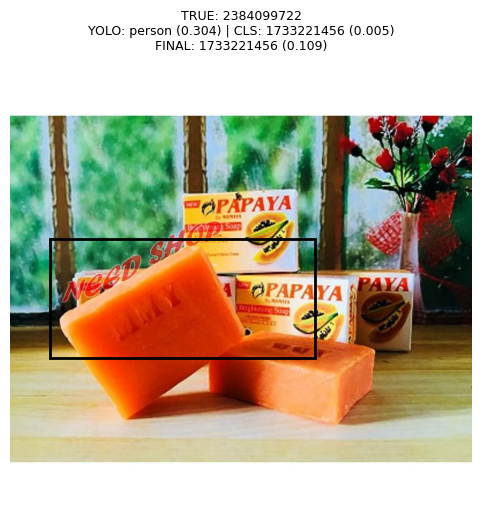

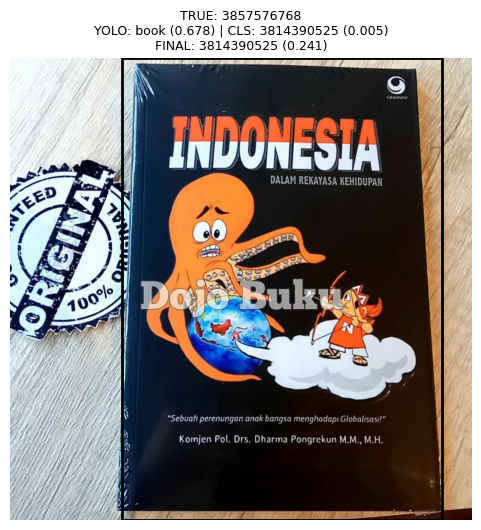

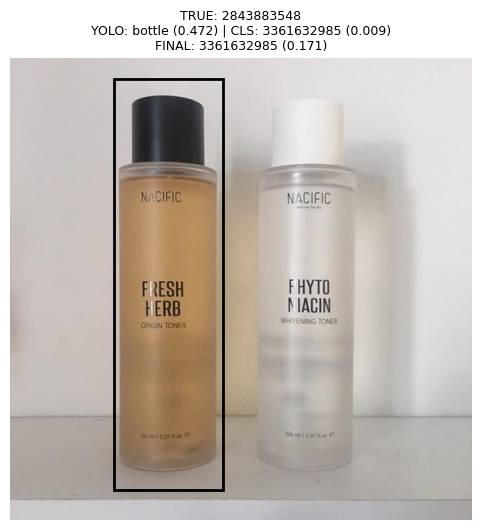

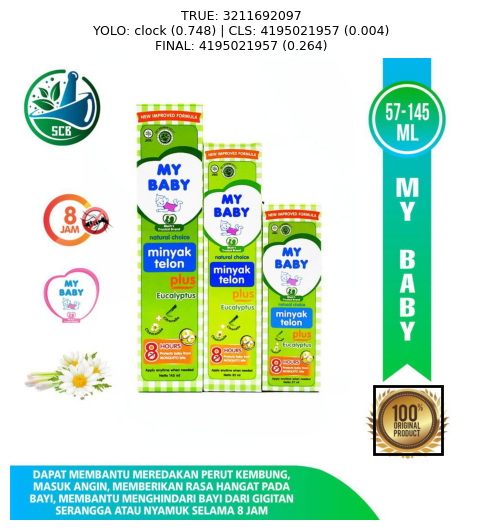

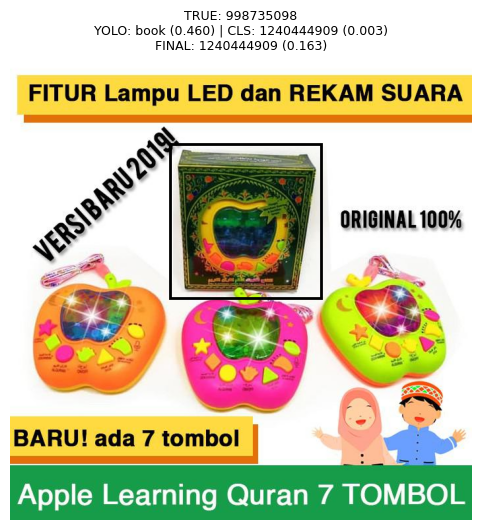


Phương pháp thử nghiệm sử dụng pipeline hai tầng gồm YOLO + SAHI để phát hiện vùng vật thể, sau đó crop bbox và đưa vào efficientnet_b0 để phân loại lại.
SAHI được dùng nhằm cải thiện khả năng phát hiện vật thể nhỏ bằng cách chia ảnh thành nhiều lát nhỏ trước khi chạy detector.
Kết quả cuối cùng được tạo bằng soft fusion giữa độ tin cậy của YOLO và độ tin cậy của crop classifier:

final_score = 0.35 * yolo_conf + 0.65 * classifier_conf

Kết quả validation:
- classifier_accuracy@1 = 0.0200
- final_accuracy@1 = 0.0200
- classifier_top5_accuracy = 0.0350
- fallback_full_image_ratio = 0.0900

Lưu ý: nếu detector đang dùng pretrained COCO như yolo11n.pt/yolov8s.pt thì YOLO chủ yếu đóng vai trò định vị crop. Muốn fusion nhãn tốt hơn thì cần fine-tune YOLO bằng bbox custom.

Saved report text: ..\results\yolo_sahi_crop_classifier\REPORT_yolo_sahi_crop_classifier_comment.txt


In [12]:
# ==============================
# 10. MAIN RUN
# ==============================

def main():
    df = load_dataframe()
    detector = load_detector()

    det_df = run_detection_and_crop(df, detector)
    print("det_df:", det_df.shape)
    if len(det_df):
        print("Fallback full image ratio:", det_df["used_fallback_full_image"].mean())

    train_df, val_df, class_names, class_to_idx, num_classes = prepare_train_val(det_df)
    model, criterion, val_loader, history_df, best_model_path = train_classifier(train_df, val_df, num_classes)

    pred_df, summary_df = run_final_evaluation(
        model=model,
        criterion=criterion,
        val_loader=val_loader,
        val_df=val_df,
        class_names=class_names,
        class_to_idx=class_to_idx,
        num_classes=num_classes,
    )

    # Visualize vài ảnh mẫu
    if len(pred_df) > 0:
        sample_show = pred_df.sample(n=min(5, len(pred_df)), random_state=SEED)
        for _, row in sample_show.iterrows():
            draw_prediction(row)

    report_text = f"""
Phương pháp thử nghiệm sử dụng pipeline hai tầng gồm YOLO + SAHI để phát hiện vùng vật thể, sau đó crop bbox và đưa vào {CLASSIFIER_BACKBONE} để phân loại lại.
SAHI được dùng nhằm cải thiện khả năng phát hiện vật thể nhỏ bằng cách chia ảnh thành nhiều lát nhỏ trước khi chạy detector.
Kết quả cuối cùng được tạo bằng soft fusion giữa độ tin cậy của YOLO và độ tin cậy của crop classifier:

final_score = {FUSION_ALPHA:.2f} * yolo_conf + {1 - FUSION_ALPHA:.2f} * classifier_conf

Kết quả validation:
- classifier_accuracy@1 = {summary_df.loc[0, 'classifier_accuracy@1']:.4f}
- final_accuracy@1 = {summary_df.loc[0, 'final_accuracy@1']:.4f}
- classifier_top5_accuracy = {summary_df.loc[0, 'classifier_top5_accuracy']:.4f}
- fallback_full_image_ratio = {summary_df.loc[0, 'fallback_full_image_ratio']:.4f}

Lưu ý: nếu detector đang dùng pretrained COCO như yolo11n.pt/yolov8s.pt thì YOLO chủ yếu đóng vai trò định vị crop. Muốn fusion nhãn tốt hơn thì cần fine-tune YOLO bằng bbox custom.
"""
    print(report_text)

    report_path = RESULTS_DIR / "REPORT_yolo_sahi_crop_classifier_comment.txt"
    report_path.write_text(report_text, encoding="utf-8")
    print("Saved report text:", report_path)

    return {
        "df": df,
        "det_df": det_df,
        "train_df": train_df,
        "val_df": val_df,
        "pred_df": pred_df,
        "summary_df": summary_df,
        "model": model,
        "detector": detector,
        "class_names": class_names,
        "class_to_idx": class_to_idx,
        "best_model_path": best_model_path,
    }


if __name__ == "__main__":
    main()